# Kaggle Dataset Explorer
## Schnelle Datenanalyse für Portfolio-Projekte

Dieses Notebook hilft dir dabei, Kaggle-Datasets schnell zu explorieren und zu entscheiden, ob sie für dein Portfolio-Projekt geeignet sind.

---

## 1. Setup & Daten laden



In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle

# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100



/Users/myPace/Documents/StackFuel/stackfuel-portfolio/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




## 2. Daten einlesen & erste Inspektion



In [2]:
import os
from core.brailleimages import read_cleaned

# Erste CSV-Datei laden (oder bei Bedarf anpassen)
files = ['braille.csv']
processed_folderpath = "../data/processed/braille-character-dataset"

df = read_cleaned(os.path.join(processed_folderpath, files[0]))

print(f"📊 Geladene Datei: {files[0]}")
print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")

df.sample(10)


📊 Geladene Datei: braille.csv
📏 Shape: 1,560 Zeilen × 787 Spalten



,0,1,2,3,4,5,6,7,8,9,...,777,778,779,780,781,782,783,letter,number,augmentation
388,250,249,251,255,240,255,244,254,255,255,...,255,255,255,254,254,255,255,g,18,rot
932,255,245,250,240,248,215,221,230,232,241,...,251,252,253,255,255,255,255,p,19,whs
1442,255,255,255,254,252,251,250,250,249,240,...,245,241,255,249,251,252,254,y,0,whs
778,252,253,254,253,249,246,248,252,253,255,...,255,253,252,252,253,254,255,m,9,rot
362,255,241,253,241,253,244,250,255,255,255,...,255,253,251,254,254,254,254,g,0,whs
1233,162,163,156,162,173,161,161,160,163,170,...,156,174,151,163,163,163,163,u,1,dim
1381,250,255,255,241,248,255,253,255,251,251,...,255,250,255,253,253,253,253,x,0,rot
1052,246,250,255,255,250,255,254,237,252,250,...,248,254,255,255,255,255,255,r,19,whs
791,244,255,253,253,242,251,255,169,77,33,...,252,253,255,255,254,253,252,n,12,whs
1171,252,253,253,252,251,248,246,244,253,246,...,255,255,255,255,255,255,255,t,19,rot




---

## 3. Datenqualität & Struktur



In [3]:

print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 1,560 Zeilen × 787 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 1.17 MB


In [4]:
# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Beispielwerte
0,uint8,0,0.0,199,"[254, 101, 252]"
1,uint8,0,0.0,210,"[255, 246, 208]"
2,uint8,0,0.0,211,"[242, 114, 241]"
3,uint8,0,0.0,217,"[53, 255, 255]"
4,uint8,0,0.0,218,"[255, 122, 254]"
...,...,...,...,...,...
782,uint8,0,0.0,188,"[252, 255, 255]"
783,uint8,0,0.0,186,"[84, 255, 140]"
letter,category,0,0.0,26,"[a, c, b]"
number,category,0,0.0,20,"[19, 6, 3]"




---

## 4. Numerische Variablen analysieren



In [5]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 785 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
0,1560.0,214.10,61.48,28.0,188.75,249.0,254.00,255.0
1,1560.0,212.25,63.72,5.0,186.75,249.0,254.00,255.0
2,1560.0,211.56,63.95,12.0,181.75,249.0,254.00,255.0
3,1560.0,210.19,64.82,16.0,177.00,248.0,254.00,255.0
4,1560.0,209.90,65.12,14.0,180.00,248.0,253.00,255.0
...,...,...,...,...,...,...,...,...
780,1560.0,218.42,58.73,27.0,199.75,253.0,255.00,255.0
781,1560.0,219.36,58.35,51.0,201.75,253.0,255.00,255.0
782,1560.0,219.87,58.43,51.0,204.00,254.0,255.00,255.0
783,1560.0,220.14,58.54,51.0,204.00,254.0,255.00,255.0


In [ ]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()




---

## 5. Kategorische Variablen analysieren



In [6]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


🏷️ 2 kategorische Spalten gefunden



,Spalte,Unique Werte,Häufigste Werte
0,letter,26,"{'a': 60, 'b': 60, 'c': 60}"
1,augmentation,3,"{'dim': 520, 'rot': 520, 'whs': 520}"


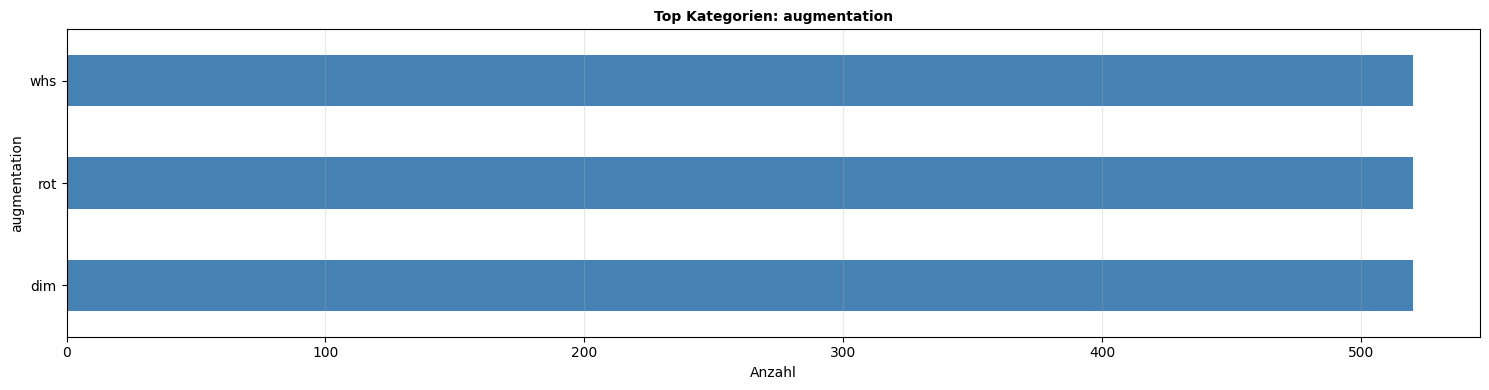

In [7]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()




---

## 6. Korrelationsanalyse



In [ ]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [8]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")


✅ Keine fehlenden Werte im Dataset!




---

## 8. Zusammenfassung & Bewertung



In [9]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT
Datengröße.................... ⚠️ Klein
Vollständigkeit............... ✅ 100.0%
Duplikate..................... ✅ Keine
Variablenvielfalt............. ✅ 787 Spalten
Numerische Features........... ✅ 785 Spalten
Kategorische Features......... ✅ 2 Spalten

💡 EMPFEHLUNG:
✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!

📌 Nächste Schritte:
   1. Definiere deine Forschungsfrage
   2. Identifiziere relevante Features
   3. Plane deine Analysestrategie
   4. Beginne mit Feature Engineering & Modeling
